<a href="https://colab.research.google.com/github/dashakudjaeva/HW/blob/hw_1/HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Постановка задачи и описание датасета**

**Бизнес-постановка**

Телеком-оператор сталкивается с проблемой оттока клиентов (churn). Ежемесячно часть клиентов прекращает пользоваться услугами, что приводит к потере дохода. Чтобы удерживать клиентов, компания хочет заранее выявлять тех, кто с высокой вероятностью уйдёт, и предлагать им персонализированные предложения (скидки, бонусы, улучшение качества обслуживания).

Цель: разработать модель машинного обучения, которая по историческим данным о клиенте предскажет вероятность его оттока в ближайшем будущем.

**ML-постановка**

Задача относится к классу бинарной классификации. Выходная переменная Churn принимает два значения:

Yes – клиент ушёл,
No – клиент остался.

**Описание набора данных**

Датасет Telco Customer Churn (источник: Kaggle) содержит информацию о клиентах телекоммуникационной компании. Всего 7043 записи и 21 признак.

Колонки:
* customerID – уникальный идентификатор клиента.
* gender – пол клиента (Female / Male).
* SeniorCitizen – является ли клиент пожилым (1 = да, 0 = нет).
* Partner – наличие партнёра (Yes / No).
* Dependents – наличие иждивенцев (Yes / No).
* tenure – количество месяцев, в течение которых клиент остаётся с компанией.
* PhoneService – наличие телефонной линии (Yes / No).
* MultipleLines – наличие нескольких телефонных линий (Yes / No / No phone service).
* InternetService – тип интернет-услуг (DSL / Fiber optic / No).
* OnlineSecurity – услуга онлайн-безопасности (Yes / No / No internet service).
* OnlineBackup – услуга онлайн-резервного копирования (Yes / No / No internet service).
* DeviceProtection – защита устройств (Yes / No / No internet service).
* TechSupport – техническая поддержка (Yes / No / No internet service).
* StreamingTV – стриминг ТВ (Yes / No / No internet service).
* StreamingMovies – стриминг фильмов (Yes / No / No internet service).
* Contract – тип контракта (Month-to-month / One year / Two year).
* PaperlessBilling – электронный счёт (Yes / No).
* PaymentMethod – способ оплаты (Electronic check / Mailed check / Bank transfer (automatic) / Credit card (automatic)).
* MonthlyCharges – ежемесячная плата (в долларах).
* TotalCharges – общая сумма, оплаченная клиентом за всё время (в долларах).
* Churn – целевая переменная: отток (Yes / No).

**2. Выбор метрики оценки качества**

Классы в данных несбалансированы (около 73% клиентов остаются, 27% уходят). В такой ситуации точность (accuracy) может быть обманчива, так как модель, всегда предсказывающая "No", покажет высокую точность, но не будет полезна.

Бизнес-цель – минимизировать как ложные срабатывания (предложение скидки клиенту, который и так бы остался), так и ложные пропуски (упустить клиента, который уйдёт). Однако удержание клиента часто важнее, поэтому стоит сделать акцент на полноте (recall) для класса оттока.

Оптимальной метрикой является F1-мера (среднее гармоническое точности и полноты) для класса Churn = Yes. Также можно использовать ROC-AUC, который оценивает способность модели разделять классы независимо от порога.

Обоснование: F1-score позволяет сбалансировать точность и полноту, что важно при дисбалансе классов. ROC-AUC даёт интегральную оценку качества ранжирования, но менее интерпретируема для бизнеса. В данном проекте будем ориентироваться на F1-меру для положительного класса, дополнительно отслеживая полноту (recall).

**3. Разведочный анализ данных (EDA)**

3.1 Импорт библиотек и загрузка данных

In [ ]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Настройки визуализации
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# Загрузка данных
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Размер датасета: {df.shape}')
df.head()

Размер датасета: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Общая информация
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# Статистика числовых признаков
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


3.2 Обработка пропусков и преобразование типов

In [6]:
# Преобразование TotalCharges в число, заполнение пропусков
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'Пропуски в TotalCharges до обработки: {df["TotalCharges"].isnull().sum()}')

median_total = df['TotalCharges'].median()
df['TotalCharges'].fillna(median_total, inplace=True)
print(f'Пропуски после заполнения: {df["TotalCharges"].isnull().sum()}')

# Создаём бинарную целевую переменную
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

Пропуски в TotalCharges до обработки: 11
Пропуски после заполнения: 0


/tmp/ipykernel_7256/1187871510.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(median_total, inplace=True)


В столбце TotalCharges обнаружено 11 пропусков (0,16% от общего объёма данных). Это очень мало, поэтому заполнение медианой (или средним) не исказит распределение. Медиана выбрана как более устойчивая к выбросам статистика. Дополнительно создана бинарная целевая переменная Churn_binary, что упростит дальнейшее моделирование.

3.3 Распределение целевой переменной

Churn
No     5174
Yes    1869
Name: count, dtype: int64


/tmp/ipykernel_7256/1973229164.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


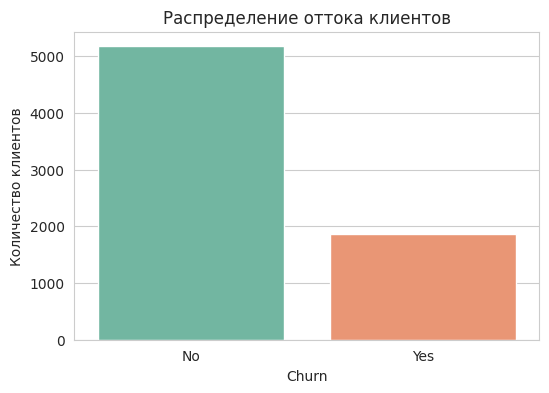

In [7]:
# Распределение Churn
churn_counts = df['Churn'].value_counts()
print(churn_counts)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Распределение оттока клиентов')
plt.ylabel('Количество клиентов')
plt.show()

In [14]:
# Интерактивная круговая диаграмма (plotly)
fig = px.pie(df, names='Churn', title='Доля оттока клиентов', hole=0.3)
fig.show()

Классы Churn несбалансированы: 5174 клиента (73,5%) остались, 1869 (26,5%) ушли. Такой дисбаланс необходимо учитывать при выборе метрики оценки качества модели (например, мы будем использовать F1-score, ROC-AUC, а не accuracy) и при обучении (применять методы балансировки классов, такие как взвешивание классов, oversampling или undersampling).

3.4 Анализ категориальных признаков

In [9]:
# Список категориальных признаков
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
            'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

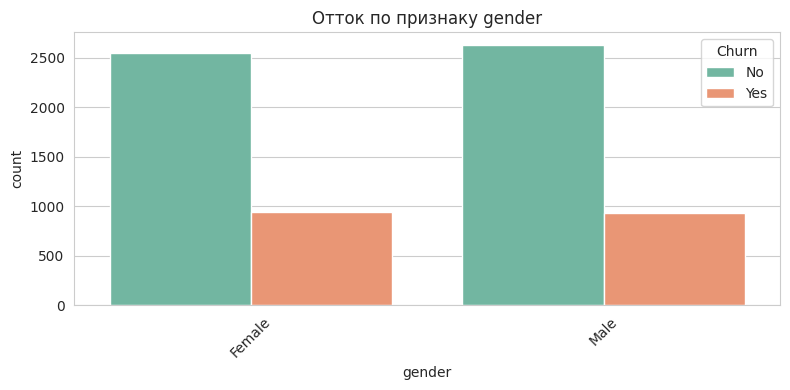

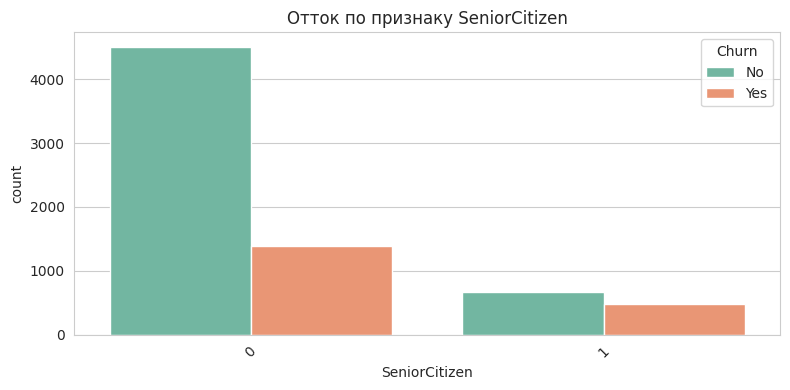

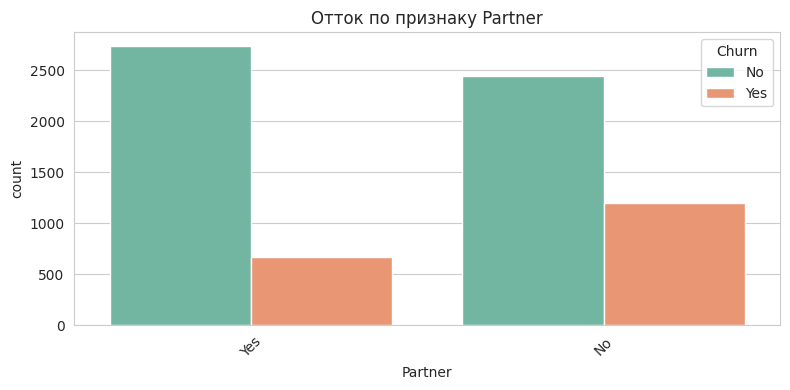

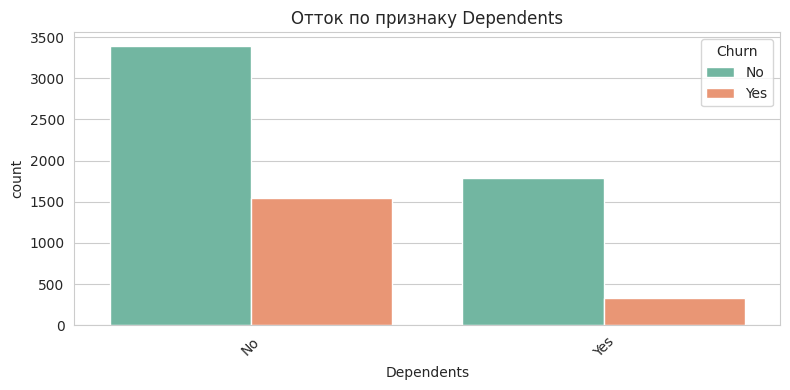

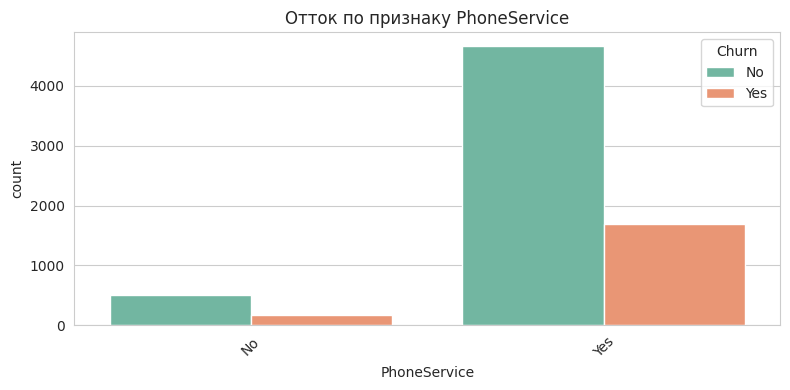

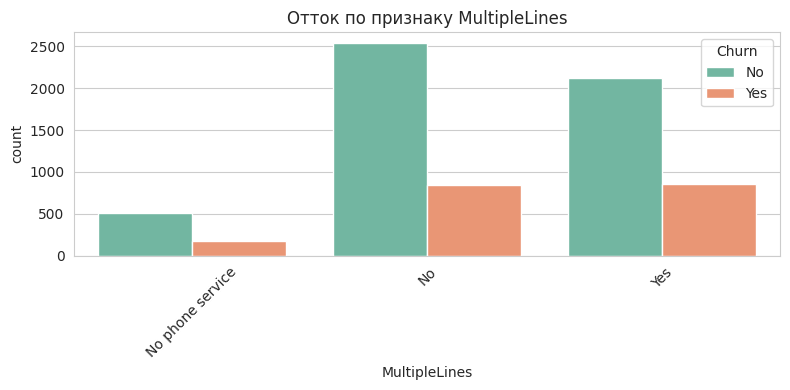

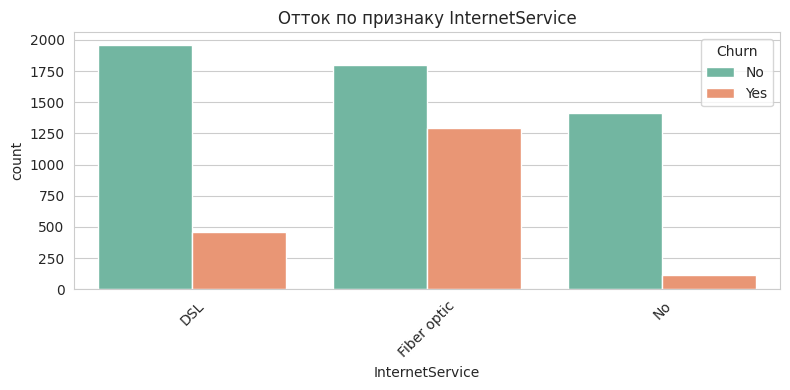

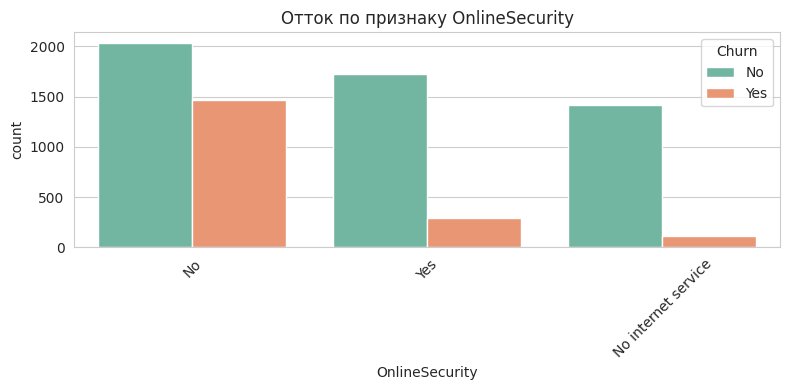

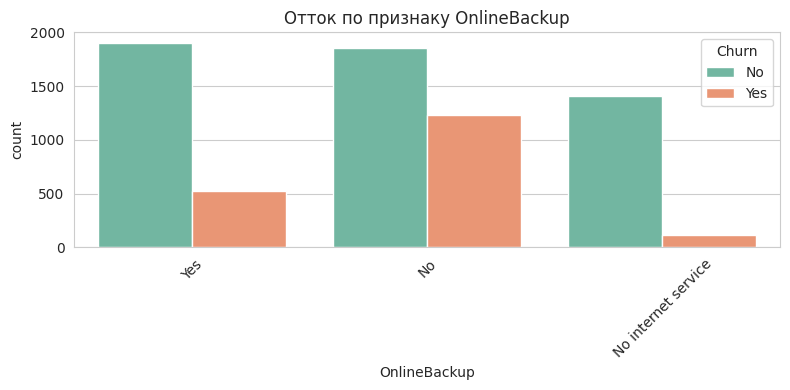

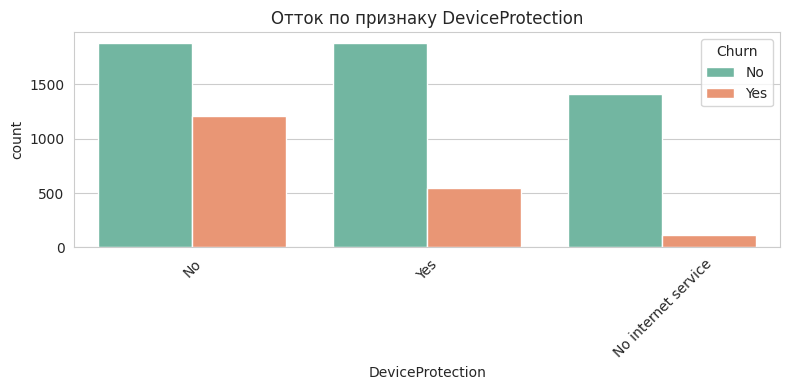

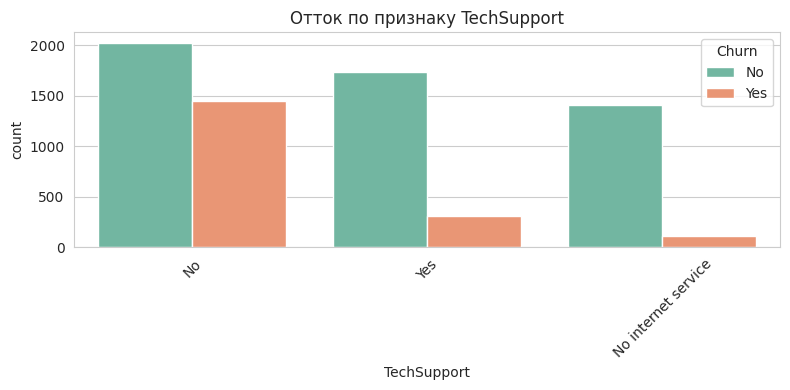

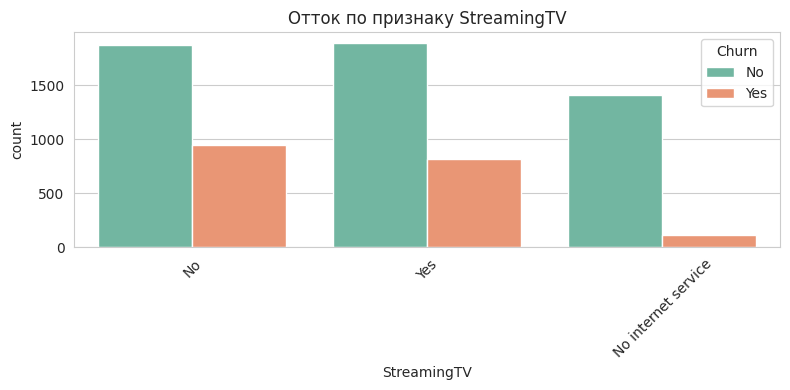

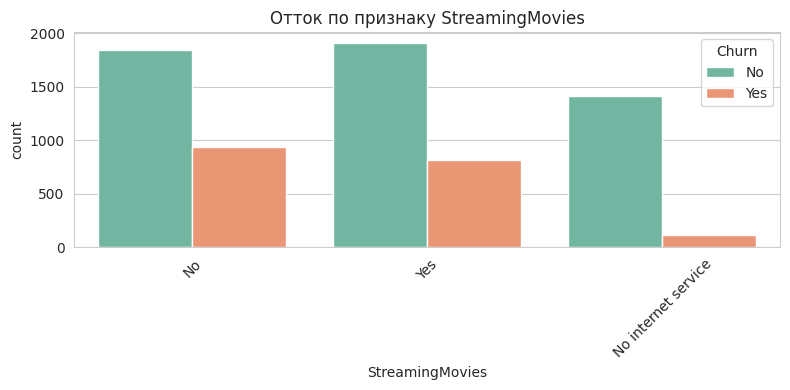

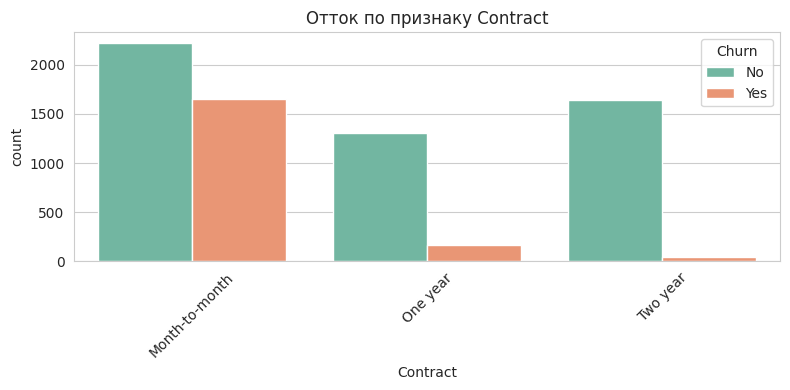

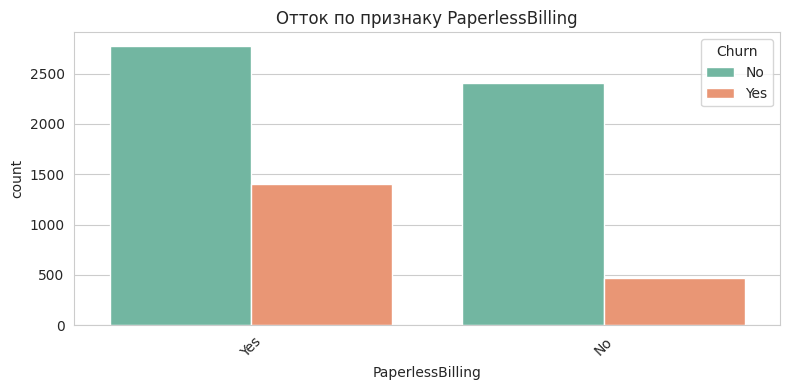

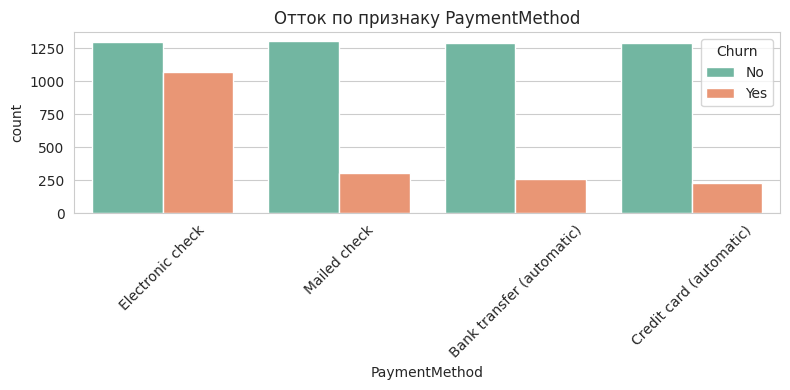

In [10]:
# Визуализация оттока по каждому категориальному признаку
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue='Churn', palette='Set2')
    plt.title(f'Отток по признаку {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

На графиках хорошо видно, какие категории наиболее ассоциированы с оттоком:

* Contract: месячный контракт (Month-to-month) даёт наибольшую долю оттока, тогда как долгосрочные контракты (One year, Two year) значительно снижают вероятность ухода. Это один из самых сильных признаков.
* PaymentMethod: клиенты, использующие Electronic check, уходят гораздо чаще, чем те, у кого настроены автоматические платежи (Bank transfer (automatic), Credit card (automatic)) или оплата по почте (Mailed check).
* InternetService: у клиентов с оптоволокном (Fiber optic) отток выше, чем с DSL или без интернета. Это может быть связано с более высокой стоимостью или качеством услуги.
* OnlineSecurity, TechSupport, OnlineBackup, DeviceProtection: клиенты, не использующие эти дополнительные услуги, имеют более высокий отток. Это указывает на то, что наличие «защитных» услуг повышает лояльность.
* SeniorCitizen: пожилые клиенты (1) чаще уходят, хотя разница не столь драматична.
* Gender, Partner, Dependents показывают небольшие различия в оттоке, но их влияние может быть незначительным.

Шаги для обучения:
Категориальные признаки можно закодировать (one-hot encoding или ordinal encoding для упорядоченных, таких как Contract). При создании модели можно провести отбор признаков, чтобы исключить наименее информативные.

3.5 Анализ числовых признаков

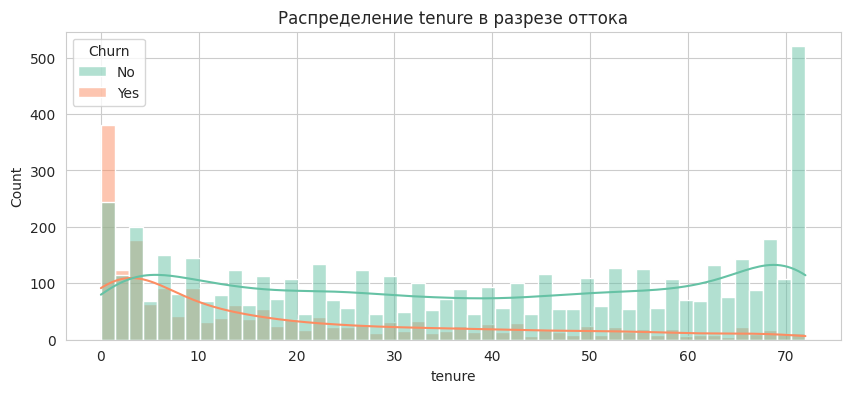

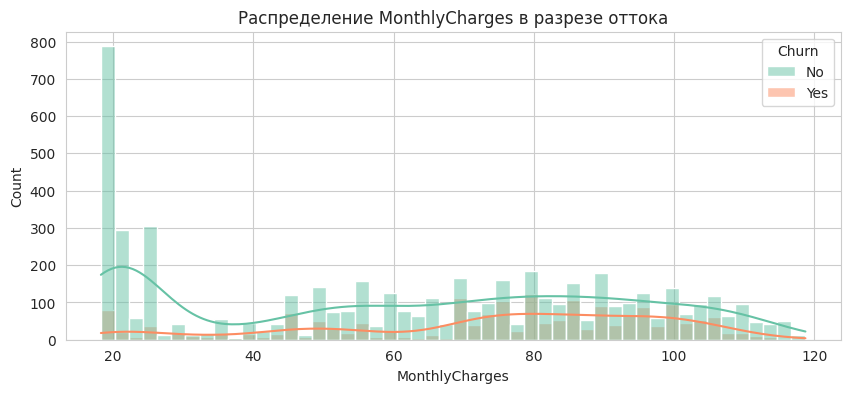

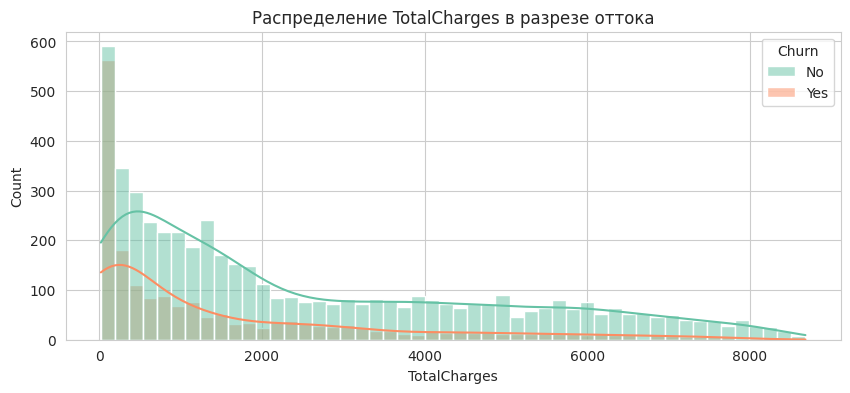

In [11]:
# Числовые признаки
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_cols:
    plt.figure(figsize=(10,4))
    sns.histplot(data=df, x=col, hue='Churn', kde=True, bins=50, palette='Set2')
    plt.title(f'Распределение {col} в разрезе оттока')
    plt.show()

/tmp/ipykernel_7256/3472771244.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




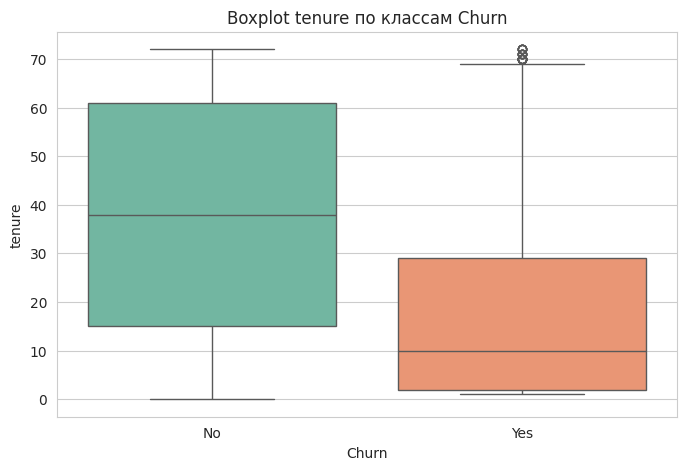

/tmp/ipykernel_7256/3472771244.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




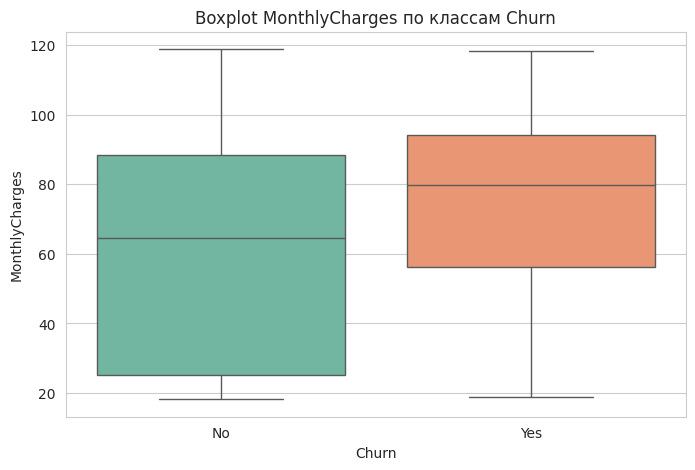

/tmp/ipykernel_7256/3472771244.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




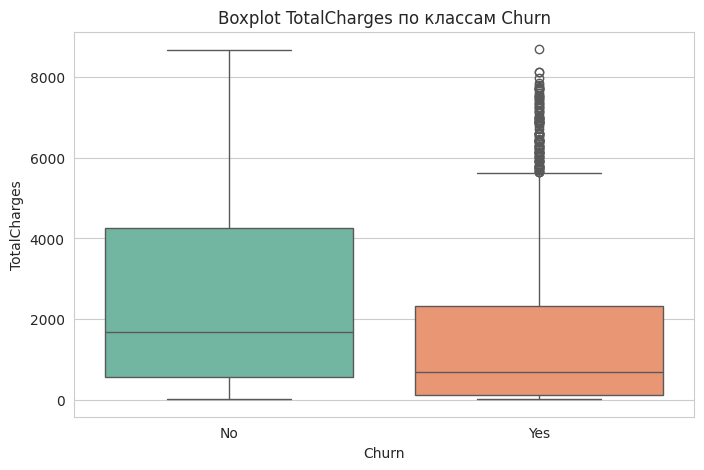

In [12]:
# Ящики с усами
for col in num_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x='Churn', y=col, palette='Set2')
    plt.title(f'Boxplot {col} по классам Churn')
    plt.show()

* Tenure: распределение ушедших клиентов смещено влево – большинство из них имеют небольшой срок обслуживания (до 20 месяцев). Оставшиеся клиенты в среднем остаются дольше. Это подтверждает, что риск оттока особенно высок в первые месяцы.
* MonthlyCharges: у ушедших клиентов медиана ежемесячных платежей выше, чем у оставшихся. Более дорогие тарифы (особенно волоконный интернет) коррелируют с оттоком.
* TotalCharges: логично, что у оставшихся клиентов суммарные расходы выше, так как они пользуются услугами дольше. У ушедших этот показатель ниже.

Ящики с усами наглядно показывают различия медиан и разброса значений по классам. Эти признаки являются важными предикторами. При подготовке данных их следует масштабировать, чтобы избежать доминирования признаков с большими значениями в моделях, чувствительных к масштабу.

3.6 Корреляционный анализ

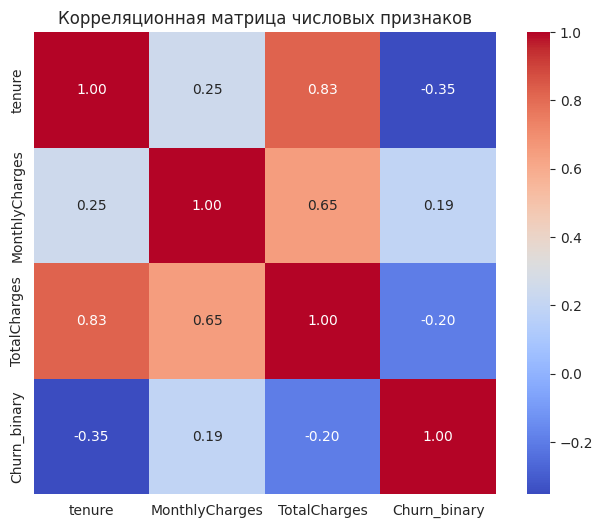

In [15]:
# Корреляционная матрица
num_features = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_binary']]
corr = num_features.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Корреляционная матрица числовых признаков')
plt.show()

Корреляционная матрица числовых признаков показывает:

* tenure и TotalCharges имеют высокую положительную корреляцию (0.83), что ожидаемо – чем дольше клиент, тем больше он платит.
* tenure отрицательно коррелирует с Churn (-0.35): длительное пребывание снижает вероятность оттока.
* MonthlyCharges положительно коррелирует с Churn (0.19): высокие ежемесячные платежи увеличивают риск ухода.
* TotalCharges также отрицательно коррелирует с Churn (-0.20), что связано с tenure.
Мультиколлинеарность между tenure и TotalCharges может быть проблемой для линейных моделей; MonthlyCharges не сильно коррелирует с tenure (0.25), поэтому оба признака могут быть полезны.

3.7 Интерактивные визуализации (plotly)

In [16]:
# Scatter plot tenure vs MonthlyCharges
fig = px.scatter(df, x='tenure', y='MonthlyCharges', color='Churn',
                 hover_data=['Contract', 'InternetService'],
                 title='Отток в зависимости от срока обслуживания и ежемесячных платежей')
fig.show()

In [17]:
# Средний отток по Contract и PaymentMethod
agg_df = df.groupby(['Contract', 'PaymentMethod'])['Churn_binary'].mean().reset_index()
fig = px.bar(agg_df, x='Contract', y='Churn_binary', color='PaymentMethod',
             barmode='group', title='Доля оттока в зависимости от типа контракта и способа оплаты')
fig.show()

* Scatter plot (tenure vs MonthlyCharges): на графике отчётливо видно, что точки, соответствующие оттоку (красные), сконцентрированы в области малого tenure и высоких ежемесячных платежей. Это подтверждает гипотезу о том, что «дорогие новички» наиболее склонны уходить. При этом клиенты с долгосрочными контрактами (Two year) почти всегда остаются.
* Bar plot (Contract vs PaymentMethod): диаграмма наглядно показывает, что максимальная доля оттока наблюдается у клиентов с месячным контрактом и способом оплаты Electronic check. У двухлетних контрактов отток минимален, независимо от способа оплаты. Это важный инсайт для бизнеса: можно стимулировать переход на долгосрочные контракты и автоматические способы оплаты.

3.8 Анализ взаимодействия признаков

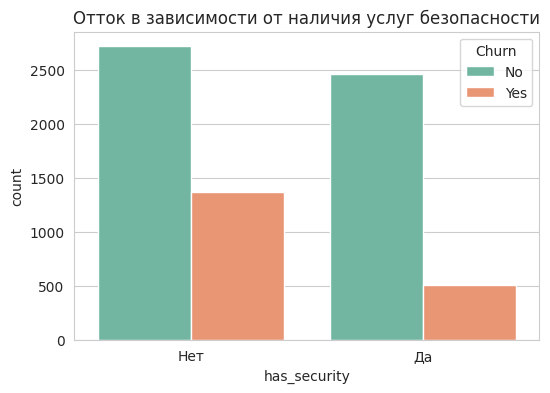

In [18]:
# Создаём признак наличия услуг безопасности
df['has_security'] = ((df['OnlineSecurity'] == 'Yes') | (df['TechSupport'] == 'Yes')).astype(int)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='has_security', hue='Churn', palette='Set2')
plt.title('Отток в зависимости от наличия услуг безопасности')
plt.xticks([0,1], ['Нет', 'Да'])
plt.show()

Создан комбинированный признак has_security (наличие хотя бы одной из услуг OnlineSecurity или TechSupport). График показывает, что среди клиентов, не использующих эти услуги, доля оттока значительно выше (38% против 18% у тех, у кого есть защита). Это говорит о том, что такие услуги играют важную роль в удержании. В модели стоит использовать как отдельные признаки OnlineSecurity и TechSupport, так и их комбинацию, чтобы уловить синергетический эффект.

**4. Выводы по EDA**

Выводы по EDA

1. Ключевые факторы оттока:
* Тип контракта (особенно месячный).
* Способ оплаты (особенно электронный чек).
* Наличие дополнительных услуг безопасности (OnlineSecurity, TechSupport).
* Низкий срок обслуживания (tenure).
* Высокие ежемесячные платежи (особенно у волоконного интернета).

2. Дисбаланс классов: требуется использовать соответствующие метрики (F1, ROC-AUC) и методы борьбы с дисбалансом.

3. Предобработка:
* Заполнение пропусков медианой (уже сделано).
* Кодирование категориальных признаков (one‑hot encoding).
* Масштабирование числовых признаков.
* Стоит удалить customerID (не информативен) и, возможно, один из коррелирующих признаков (tenure или TotalCharges) для линейных моделей.

4. Возможные проблемы:
* Мультиколлинеарность между tenure и TotalCharges.
* Высокая размерность после one‑hot encoding (много категорий).
* Необходимость проверки на выбросы в числовых признаках.


5. Что важно для последующего моделирование:
* Использовать кросс-валидацию с учётом стратификации по целевому признаку.
* Провести отбор признаков для повышения интерпретируемости и снижения переобучения.